### prepair modules and bases settings

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix,  classification_report, log_loss
from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier
from scipy.stats import norm
import scipy.io
import re
import itertools

import os
from os.path import join
import contextlib
from copy import deepcopy
import imp 
import time 
import sys

import pickle
from pdb import set_trace

from IPython.display import clear_output, display

In [14]:
# Add the directory containing your modules to the Python path
sys.path.append(os.path.abspath(os.path.join('..', 'ses2_modelstims')))

# load local functions
import stim_io
import stim_io_plotting
import vtc
import bvbabel

In [15]:
import regression
import varpar
import stats

In [16]:
## LOADING GRID

# Load from MAT file
variables = scipy.io.loadmat('/media/jorvhar/Data8T/MRIData/timing data/grid_parameters_python.mat')

# Extract individual variables
tunsteps = variables['tunsteps']
freqstep = variables['freqstep']
subsample = variables['subsample']
mustep = variables['mustep']
muarray_bins = variables['muarray_bins']
muarray = variables['muarray']
fwhm = variables['fwhm']
octgrid = variables['octgrid']
sigmagrid = variables['sigmagrid']
pref_range = variables['pref_range']
sharp_range_fwhm = variables['sharp_range_fwhm']
sharp_range = variables['sharp_range']

## 1. Load Regression Parameters for easier parsing
Options:

In [17]:
### --- LOCATION OPTIONS ---

# file location
mridat_dir = '/media/jorvhar/Data8T/MRIData/PreProc'

# tonotopy and mask filenames
tonotopy_vmp = 'prf_permutations_for_s2.vmp'
mask_fn = 'gm-subcortical.msk'
pp_dir = lambda pp, ses : f'S{pp:02d}_SES{ses}'

### --- PARTICIPANT OPTIONS ---

# session of interest
ses = 2

# variable that may be different per participant
ppz = [1,2,3,4,5,6,7,8,9,10]
n_splitsz = [6,6,5,5,5,5,5,5,5,5]               # 12 runs > 10:2cross, 6 fold, splits used per pp (for variable length option)
n_runz = [12,12,10,10,10,10,10,10,10,10]        # number of runs
startpp = 1

In [32]:
pp = 2
scores_fn = ' ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset_winning.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    
    
### --- SET THEORIE REGRESSION MODELS ---

# obtain all models
models = list(scores.keys())[:-1]
# obtain all model regressors
model_regressors = {model : scores[model]['feature_labels'] for model in models} 

In [30]:
### --- SANITY CHECK DIMENSIONALLITY REGRESSION ---

# rois
rois = ['HG', 'PP', 'PT', 'aSTG', 'pSTG']
hemispheres = ['combined']  #''LH', 'RH''

# get total length
total_length = scores['indexes'][0].shape

# loop over models and check if shape is ok
for model in models:
    
    print(f"Model: {model}, has {len(scores[model]['feature_labels'])} coeffs")
    
    # check if the intercept matches
    if scores[model]['intercepts']['mean'].shape[0] != total_length[0]: 
        print(f'error in {model}, shape mismatch for intercept')
        
    # check if the regressors match
    if scores[model]['coefs']['mean'].shape != (total_length[0], len(scores[model]['feature_labels'])): 
        print(f"error in {model}, shape mismatch for coefs (expected: {len(scores[model]['feature_labels'])}, was {scores[model]['coefs']['mean'].shape})")
        
# check size
len_05 = np.sum(scores['base_U_adaptation_U_prediction']['non-cv']['p_value'] < 0.05)
len_001 = np.sum(scores['base_U_adaptation_U_prediction']['non-cv']['p_value'] < 0.001)
len_0001 = np.sum(scores['base_U_adaptation_U_prediction']['non-cv']['p_value'] < 0.0001)
len_all = len(scores['base_U_adaptation_U_prediction']['non-cv']['p_value'])
# print overall sizes
print(f'\nNumber of sig voxels:')
print(f" -p < 0.05: \t {len_05}-voxels \t {len_05 * 100 / len_all:.2f}%")
print(f" -p < 0.001: \t {len_001}-voxels \t {len_001 * 100 / len_all:.2f}%")
print(f" -p < 0.0001: \t {len_0001}-voxels \t {len_0001 * 100 / len_all:.2f}%\n")

# generate lin indexing for areas oi
indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'])
for roi in indx_dict_nl.keys():
    indx_dict_nl[roi]
    
    # sellect
    scores_sel = scores['base_U_adaptation_U_prediction']['non-cv']['p_value'][indx_dict_nl[roi]]
    
    # check size
    len_05 = np.sum(scores_sel < 0.05)
    len_001 = np.sum(scores_sel < 0.001)
    len_0001 = np.sum(scores_sel < 0.0001)
    len_all = len(scores_sel)
    # print overall sizes
    print(f'{roi}:')
    print(f" -p < 0.05: \t {len_05}-voxels \t {len_05 * 100 / len_all:.2f}%")
    print(f" -p < 0.001: \t {len_001}-voxels \t {len_001 * 100 / len_all:.2f}%")
    print(f" -p < 0.0001: \tz {len_0001}-voxels \t {len_0001 * 100 / len_all:.2f}%")
    

Model: base, has 2 coeffs
Model: adaptation, has 1 coeffs
Model: prediction, has 4 coeffs
Model: base_U_adaptation, has 3 coeffs
Model: base_U_prediction, has 6 coeffs
Model: adaptation_U_prediction, has 5 coeffs
Model: base_U_adaptation_U_prediction, has 7 coeffs

Number of sig voxels:
 -p < 0.05: 	 190414-voxels 	 20.61%
 -p < 0.001: 	 33488-voxels 	 3.62%
 -p < 0.0001: 	 13384-voxels 	 1.45%

HG_combined:
 -p < 0.05: 	 2827-voxels 	 30.22%
 -p < 0.001: 	 858-voxels 	 9.17%
 -p < 0.0001: 	z 496-voxels 	 5.30%
PP_combined:
 -p < 0.05: 	 1866-voxels 	 22.12%
 -p < 0.001: 	 422-voxels 	 5.00%
 -p < 0.0001: 	z 211-voxels 	 2.50%
PT_combined:
 -p < 0.05: 	 2165-voxels 	 26.62%
 -p < 0.001: 	 543-voxels 	 6.68%
 -p < 0.0001: 	z 276-voxels 	 3.39%
aSTG_combined:
 -p < 0.05: 	 3232-voxels 	 20.92%
 -p < 0.001: 	 639-voxels 	 4.14%
 -p < 0.0001: 	z 273-voxels 	 1.77%
pSTG_combined:
 -p < 0.05: 	 5336-voxels 	 21.62%
 -p < 0.001: 	 985-voxels 	 3.99%
 -p < 0.0001: 	z 403-voxels 	 1.63%


## Generate comparable maps
generate maps for comparison that incluse **fval** for full model, **pval** for full model, **r2** for fullmodel and for unqiue* portions, **coeffs** values for all coeffs within full model

In [153]:

for pp in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    

    scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
    betas_dir = 'Betas'
    models_oi = 'base_U_adaptation_U_prediction'

    # and of results
    with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
        scores = pickle.load(handle)

    # gather fmap info
    fm = {f'{models_oi}-fmap' : scores[models_oi]['non-cv']['fmap']}
    pv = {f'{models_oi}-pval' : 1-scores[models_oi]['non-cv']['p_value']}

    # gather coeffs info for full model
    cf = {f'coeff_{it}' : scores[models_oi]['coefs']['mean'][:, indx] for indx, it in 
          enumerate(scores[models_oi]['feature_labels'])}

    # gather r2 vallues for full model and unique
    set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['mean'],
                                          scores['adaptation']['raw_scores']['mean'],
                                          scores['prediction']['raw_scores']['mean'],
                                          scores['base_U_adaptation']['raw_scores']['mean'],
                                          scores['base_U_prediction']['raw_scores']['mean'],
                                          scores['adaptation_U_prediction']['raw_scores']['mean'],
                                          scores['base_U_adaptation_U_prediction']['raw_scores']['mean'],
                                          correct_R2s=False)
    # create dataframe from varpar results
    r2df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)
    r2s = {f'R2s_{col}': r2df[col].to_numpy() for col in ['Baseline_u_Adaptation_u_Expectation', 
                                                        'Baseline*', 
                                                        'Adaptation*',
                                                        'Expectation*']}

    # reoraganize
    df = pd.DataFrame({**fm, **pv, **cf, **r2s})

    # loading dummy vmp for saving purposes (for shape and header info)
    dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
    # save df to vmp file
    varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
                        join(mridat_dir, pp_dir(pp,2), betas_dir, f'fullmap_{scores_fn}.vmp'))

Another test to quickly save a vmp with this data per layer - adjusted for multiple activation

In [117]:
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'
models_oi = 'base_U_adaptation_U_prediction'

pp = 2

# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)

# gather fmap info
fm = {f'{models_oi}-fmap' : scores[models_oi]['non-cv']['fmap']}
pv = {f'{models_oi}-pval' : 1-scores[models_oi]['non-cv']['p_value']}

# gather coeffs info for full model
cf = {f'coeff_{it}' : scores[models_oi]['coefs']['mean'][:, indx] for indx, it in 
      enumerate(scores[models_oi]['feature_labels'])}

# gather r2 vallues for full model and unique
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['mean'],
                                      scores['adaptation']['raw_scores']['mean'],
                                      scores['prediction']['raw_scores']['mean'],
                                      scores['base_U_adaptation']['raw_scores']['mean'],
                                      scores['base_U_prediction']['raw_scores']['mean'],
                                      scores['adaptation_U_prediction']['raw_scores']['mean'],
                                      scores['base_U_adaptation_U_prediction']['raw_scores']['mean'],
                                      correct_R2s=False)
# create dataframe from varpar results
r2df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)
r2s = {f'R2s_{col}': r2df[col].to_numpy() for col in ['Baseline_u_Adaptation_u_Expectation', 
                                                    'Baseline*', 
                                                    'Adaptation*',
                                                    'Expectation*']}

# reoraganize
df = pd.DataFrame({**fm, **pv, **cf, **r2s})

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset_winning.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
    
# set depth lambda
depthLambda = lambda hs: f'winning_WMGM_{hs}_D1-3.voi'

# hemispheres
lh = voi_dict[depthLambda('LH')]
comb = {}
comb_li = {}

# loop over layers
for layer in lh.keys():
    
    # linear index
    comb_li[layer] = stim_io.voi_idx_in_masked(scores['indexes'], lh[layer])
    # get them as og indexes
    comb[layer] = tuple(xyz[comb_li[layer]] for xyz in scores['indexes'])
    
    # sellect layer
    df_sel = df.iloc[comb_li[layer]].reset_index(drop=True)
    
    # loading dummy vmp for saving purposes (for shape and header info)
    dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
    # save df to vmp file
    varpar.save_to_vmp(df_sel, comb[layer], dummy_vmp, dummy_vmp_head, 
                        join(mridat_dir, pp_dir(pp,2), betas_dir, f'layer_test_{layer}.vmp'))

## save Maps for one participant, both fmaps and p-vals

In [118]:
pp = 2
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)

In [119]:
# gather all wanted info
fm = {f'{k}-fmap' : scores[k]['non-cv']['fmap'] for k in models}
pv = {f'{k}-pval' : 1-scores[k]['non-cv']['p_value'] for k in models}

# Create a DataFrame with the values under their respective keys
df = pd.DataFrame({**fm, **pv})
# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'fmap-ants-lwo.vmp'))

## do the same but for coeffs

In [10]:
# predifine dict
fullregdict = {}

# loop over all models
for model in model_regressors.keys():

    # get correct order of betas
    reordered_regs = [item for item in col_names if item in model_regressors[model]]

    # create regname in dicts
#         regdict = {f'PP{pp} : {model}_{it.upper()}' : scores[model]['non-cv']['coefs'][:,it_idx] for 
#                    it_idx, it in enumerate(reordered_regs)}
    regdict = {f'PP{pp} : {model}_{it.upper()}' : scores[model]['coefs']['mean'][:,it_idx] for 
               it_idx, it in enumerate(reordered_regs)}

    # append current model
    fullregdict = {**fullregdict, **regdict}

# store results in dataframe
df = pd.DataFrame(fullregdict)

# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
                    join(mridat_dir, pp_dir(pp,2), betas_dir, 'full_coeffs_cv_ANTS.vmp'))

NameError: name 'col_names' is not defined

## and lastly for the variance partioning

It seems that we can best use the median results of the model containing both precision weighting and unweighted priors

In [57]:
scores['base']['raw_scores']['mean']

array([ 9.72592774e-04, -7.20301273e-05, -1.51782329e-04, ...,
        3.56233897e-04, -6.72397455e-04, -5.00427179e-04])

In [132]:
pp = 2 
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    

# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['non-cv']['raw_scores'],
                               scores['adaptation']['non-cv']['raw_scores'],
                               scores['prediction']['non-cv']['raw_scores'],
                               scores['base_U_adaptation']['non-cv']['raw_scores'],
                               scores['base_U_prediction']['non-cv']['raw_scores'],
                               scores['adaptation_U_prediction']['non-cv']['raw_scores'],
                               scores['base_U_adaptation_U_prediction']['non-cv']['raw_scores'],
                               correct_R2s=False)

## SAVING TO VMP ##

# create dataframe from varpar results
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)

# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))

# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'set3_ants_scores_pwuw_lwo.vmp'))

In [139]:
pp = 1
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    
# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['mean'],
                               scores['adaptation']['raw_scores']['mean'],
                               scores['prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation']['raw_scores']['mean'],
                               scores['base_U_prediction']['raw_scores']['mean'],
                               scores['adaptation_U_prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['mean'],
                               correct_R2s=False)

## SAVING TO VMP ##

# create dataframe from varpar results
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)
# df = df * 100

# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))

# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'set3_ants_scores_pwuw_lwo_mean.vmp'))

In [ ]:
## another wierd things
# a lot of 0 values in the expectation values, are these filtered out sufficiently
# meaning when we do our pvalues, what do we see

# sanity check 1, 1 minus full map : shows some effected, but also a lot of good areas
# sanity check 2, check if they are common to fmaps, or 

# mark anywhere one of the main models (main 7) is zero, set a column bad - 
#  - should double check r2 results, do they change? (hopefully not too much)
# these values seems to work fine, they are mostly the values where there is just nothing there, 
#  - what we should do next is to mask these value out within the R2 analysis, just label them as bad, on top of the p value sellection
#  - then reevaluate if we still need this p>0.99 or if we can do .95 now

# I now see where this problem is comming from is within the 'three_way_varpart' function
#  - all_ABC_pluspairs[all_ABC_pluspairs<0]=0 # ignore negative input values 
#  this line makes it so that it zeros any value below zero, 
#   but this is not fully intended behaviour as the rest of the sets are still in tact

In [29]:
# gather all wanted info
pv = {f'{k}-pval' : 1-scores[k]['non-cv']['p_value'] for k in models}
df2 = pd.DataFrame(pv)

df2

,base-pval,adaptation-pval,prediction-pval,base_U_adaptation-pval,base_U_prediction-pval,adaptation_U_prediction-pval,base_U_adaptation_U_prediction-pval
0,0.972165,0.970021,0.779439,0.954532,0.996903,0.921537,0.996888
1,0.455695,0.753062,0.329084,0.750853,0.675158,0.208878,0.868615
2,0.001048,0.065562,0.793441,0.029719,0.867763,0.784566,0.803021
3,0.943523,0.707613,0.974406,0.902280,0.982151,0.984923,0.971119
4,0.583117,0.836199,0.469133,0.616626,0.906295,0.373891,0.940177
...,...,...,...,...,...,...,...
959819,0.945920,0.479763,0.998268,0.907030,0.997690,0.998357,0.997547
959820,0.504031,0.641082,0.542576,0.860221,0.943868,0.404017,0.987509
959821,0.938737,0.968142,0.876947,0.947614,0.999516,0.940549,0.999747
959822,0.902737,0.857304,0.775472,0.964469,0.791669,0.863945,0.917263


In [32]:
pd.concat([df, df2], axis=1)

,Baseline,Adaptation,Expectation,Baseline_u_Adaptation,Baseline_u_Expectation,Adaptation_u_Expectation,Baseline_u_Adaptation_u_Expectation,Baseline*,Adaptation*,Expectation*,...,Baseline_n_Adaptation,Baseline_n_Expectation,Adaptation_n_Expectation,base-pval,adaptation-pval,prediction-pval,base_U_adaptation-pval,base_U_prediction-pval,adaptation_U_prediction-pval,base_U_adaptation_U_prediction-pval
0,0.003857,0.001253,0.000000,0.001789,0.000589,0.000601,0.000000,-0.000601,-0.000589,-0.001789,...,0.003321,0.003268,0.000652,0.972165,0.970021,0.779439,0.954532,0.996903,0.921537,0.996888
1,0.000000,0.000432,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000432,0.000000,0.000432,0.455695,0.753062,0.329084,0.750853,0.675158,0.208878,0.868615
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.001048,0.065562,0.793441,0.029719,0.867763,0.784566,0.803021
3,0.004907,0.001333,0.003396,0.001119,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001119,...,0.005122,0.008303,0.004730,0.943523,0.707613,0.974406,0.902280,0.982151,0.984923,0.971119
4,0.000000,0.000375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000375,0.000000,0.000375,0.583117,0.836199,0.469133,0.616626,0.906295,0.373891,0.940177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959819,0.002908,0.000035,0.005157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.002943,0.008065,0.005192,0.945920,0.479763,0.998268,0.907030,0.997690,0.998357,0.997547
959820,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.504031,0.641082,0.542576,0.860221,0.943868,0.404017,0.987509
959821,0.001412,0.001756,0.000000,0.001333,0.003221,0.000000,0.003687,0.003687,0.000466,0.002354,...,0.001835,-0.001809,0.001756,0.938737,0.968142,0.876947,0.947614,0.999516,0.940549,0.999747
959822,0.000000,0.000527,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000527,0.000000,0.000527,0.902737,0.857304,0.775472,0.964469,0.791669,0.863945,0.917263


In [28]:
scores_fn = 'ANTS_scores_pw_uw_lwo_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)

# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
                               scores['adaptation']['raw_scores']['median'],
                               scores['prediction']['raw_scores']['median'],
                               scores['base_U_adaptation']['raw_scores']['median'],
                               scores['base_U_prediction']['raw_scores']['median'],
                               scores['adaptation_U_prediction']['raw_scores']['median'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['median'],
                               correct_R2s=False)

## SAVING TO VMP ##

# create dataframe from varpar results
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)

In [35]:
portions = ['Baseline*', 'Adaptation*','Expectation*', 
             'Baseline_n_Adaptation*', 'Baseline_n_Expectation*',
             'Adaptation_n_Expectation*', 'Baseline_n_Adaptation_n_Expectation']

Index(['Baseline', 'Adaptation', 'Expectation', 'Baseline_u_Adaptation',
       'Baseline_u_Expectation', 'Adaptation_u_Expectation',
       'Baseline_u_Adaptation_u_Expectation', 'Baseline*', 'Adaptation*',
       'Expectation*', 'Baseline_n_Adaptation*', 'Baseline_n_Expectation*',
       'Adaptation_n_Expectation*', 'Baseline_n_Adaptation_n_Expectation',
       'Baseline_n_Adaptation', 'Baseline_n_Expectation',
       'Adaptation_n_Expectation', 'base-pval', 'adaptation-pval',
       'prediction-pval', 'base_U_adaptation-pval', 'base_U_prediction-pval',
       'adaptation_U_prediction-pval', 'base_U_adaptation_U_prediction-pval'],
      dtype='object')

In [7]:
imp.reload(varpar)

<module 'varpar' from '/media/jorvhar/Data1/OneDrive_Mint/Documenten/Maastricht/processing_scripts/predadapt_fmri/ses2_regressions/varpar.py'>

In [35]:
## MAPS USED FOR PAPER / AVERAGE UNIQUE VARIANCE MAPS

# for pp in np.arange(1,11):
for pp in np.arange(1,4):
    
    scores_fn = 'abovezero_ANTS_scores_pw_uw_er_lwo_tempsmooth'
    betas_dir = 'Betas'

    # open pickle of vois (see `ROI_and_layer_ana` notebook)
    with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
        voi_dict = pickle.load(handle)
    # and of results
    with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
        scores = pickle.load(handle)

#     # calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
#     set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
#                                    scores['adaptation']['raw_scores']['median'],
#                                    scores['prediction']['raw_scores']['median'],
#                                    scores['base_U_adaptation']['raw_scores']['median'],
#                                    scores['base_U_prediction']['raw_scores']['median'],
#                                    scores['adaptation_U_prediction']['raw_scores']['median'],
#                                    scores['base_U_adaptation_U_prediction']['raw_scores']['median'],
#                                    correct_R2s=False)
    
    # calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
    set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
                                   scores['adaptation']['raw_scores']['median'],
                                   scores['prediction']['raw_scores']['median'],
                                   scores['base_U_adaptation']['raw_scores']['median'],
                                   scores['base_U_prediction']['raw_scores']['median'],
                                   scores['adaptation_U_prediction']['raw_scores']['median'],
                                   scores['base_U_adaptation_U_prediction']['raw_scores']['median'],
                                   correct_R2s=False,
                                   handle_negatives='zero')

    ## SAVING TO VMP ##

    # create dataframe from varpar results
    df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)
    
    # also get the pvalues for masking
    pv = {f'{k}-pval' : 1-scores[k]['non-cv']['p_value'] for k in models}
    pv_df = pd.DataFrame(pv)
    
    # Mask out immposible voxels
    msk = varpar.mask_varpart_impossible(df, filter_flags=[0, 0, 0, 0, 0, 0, 1])
    
    # combine dataframes
    df = pd.concat([df, pv_df], axis=1)
    
    # mask out usefull part
    df_msk = df.loc[msk == 1].copy()
    indexes_msk = tuple(xyz[np.where(msk)] for xyz in scores['indexes'])
    
    # Set relative vallues for portional parts
    portions = ['Baseline*', 'Adaptation*','Expectation*', 
                 'Baseline_n_Adaptation*', 'Baseline_n_Expectation*',
                 'Adaptation_n_Expectation*', 'Baseline_n_Adaptation_n_Expectation']
    for col in portions:
        df_msk[f'REL_{col}'] = (df_msk[col] * 100) / df_msk['Baseline_u_Adaptation_u_Expectation']
    
    # rename columns
    df_msk = df_msk.rename(columns={col: f'Subject S{pp:02d}_SES1: {col}' for col in df_msk.columns})

    # loading dummy vmp for saving purposes (for shape and header info)
    dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))

    # save df to vmp file
    varpar.save_to_vmp(df_msk, indexes_msk, dummy_vmp, dummy_vmp_head, 
                join(mridat_dir, pp_dir(pp,2), betas_dir, 'REL2-set3_ants_scores_pwuw_lwo_er_median.vmp'))

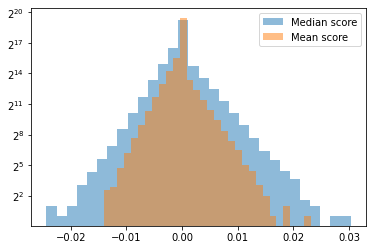

In [112]:
pp = 1
scores_fn = 'ANTS_scores_pw_uw_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    
# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
                               scores['adaptation']['raw_scores']['median'],
                               scores['prediction']['raw_scores']['median'],
                               scores['base_U_adaptation']['raw_scores']['median'],
                               scores['base_U_prediction']['raw_scores']['median'],
                               scores['adaptation_U_prediction']['raw_scores']['median'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['median'],
                               correct_R2s=False)
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)

# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['mean'],
                               scores['adaptation']['raw_scores']['mean'],
                               scores['prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation']['raw_scores']['mean'],
                               scores['base_U_prediction']['raw_scores']['mean'],
                               scores['adaptation_U_prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['mean'],
                               correct_R2s=False)
df2 = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)


plt.hist(df['Expectation*'], bins=30, alpha=0.5, label='Median score')
plt.hist(df2['Expectation*'], bins=30, alpha=0.5, label='Mean score')
plt.yscale('log', base=2)
plt.legend()

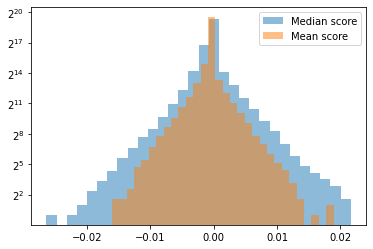

In [113]:
pp = 1
scores_fn = 'ANTS_scores_pw_uw_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    
# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
                               scores['adaptation']['raw_scores']['median'],
                               scores['prediction']['raw_scores']['median'],
                               scores['base_U_adaptation']['raw_scores']['median'],
                               scores['base_U_prediction']['raw_scores']['median'],
                               scores['adaptation_U_prediction']['raw_scores']['median'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['median'],
                               correct_R2s=True)
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)

# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['mean'],
                               scores['adaptation']['raw_scores']['mean'],
                               scores['prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation']['raw_scores']['mean'],
                               scores['base_U_prediction']['raw_scores']['mean'],
                               scores['adaptation_U_prediction']['raw_scores']['mean'],
                               scores['base_U_adaptation_U_prediction']['raw_scores']['mean'],
                               correct_R2s=True)
df2 = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','Adaptation','Expectation'], nvars=3)


plt.hist(df['Expectation*'], bins=30, alpha=0.5, label='Median score')
plt.hist(df2['Expectation*'], bins=30, alpha=0.5, label='Mean score')
plt.yscale('log', base=2)
plt.legend()

In [115]:
# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'median_corrected.vmp'))


# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
# save df to vmp file
varpar.save_to_vmp(df2, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'mean_corrected.vmp'))

(array([1.39464e+05, 2.75600e+03, 9.46000e+02, 4.38000e+02, 2.18000e+02,
        8.60000e+01, 4.40000e+01, 2.40000e+01, 4.00000e+00, 4.00000e+00]),
 array([5.11882029e-09, 7.73388256e-03, 1.54677600e-02, 2.32016375e-02,
        3.09355149e-02, 3.86693923e-02, 4.64032698e-02, 5.41371472e-02,
        6.18710247e-02, 6.96049021e-02, 7.73387796e-02]),
 <BarContainer object of 10 artists>)

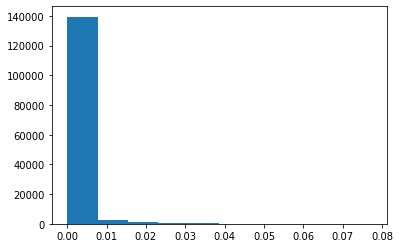

In [86]:
a2 = set3_noncv[0]
plt.hist(a2[a2>0])

In [61]:
scores['base']['non-cv']['raw_scores'].shape

(805928,)

(array([2.15800e+03, 7.91968e+05, 9.39700e+03, 1.47300e+03, 5.61000e+02,
        2.32000e+02, 8.50000e+01, 4.00000e+01, 1.00000e+01, 4.00000e+00]),
 array([-0.01503293, -0.00579576,  0.00344141,  0.01267858,  0.02191575,
         0.03115293,  0.0403901 ,  0.04962727,  0.05886444,  0.06810161,
         0.07733878]),
 <BarContainer object of 10 artists>)

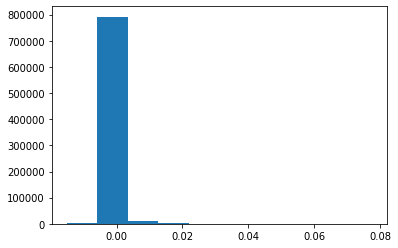

In [62]:
plt.hist(scores['base']['raw_scores']['mean'])

(array([7.99711e+05, 4.04100e+03, 1.17500e+03, 5.43000e+02, 2.60000e+02,
        1.13000e+02, 4.90000e+01, 2.60000e+01, 6.00000e+00, 4.00000e+00]),
 array([1.59797964e-09, 7.88503111e-03, 1.57700606e-02, 2.36550901e-02,
        3.15401196e-02, 3.94251491e-02, 4.73101787e-02, 5.51952082e-02,
        6.30802377e-02, 7.09652672e-02, 7.88502967e-02]),
 <BarContainer object of 10 artists>)

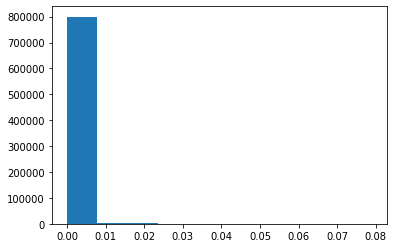

In [63]:
plt.hist(scores['base']['non-cv']['raw_scores'])

In [67]:
## where does the spotifnes in the cv maps come from,
##    should all be filled right, no reason to have missing spots

# probably the exactly 0 vallues, but then why do wo have so many of them outside the mask
df # cv

,Baseline,Adaptation,Expectation,Baseline_u_Adaptation,Baseline_u_Expectation,Adaptation_u_Expectation,Baseline_u_Adaptation_u_Expectation,Baseline*,Adaptation*,Expectation*,Baseline_n_Adaptation*,Baseline_n_Expectation*,Adaptation_n_Expectation*,Baseline_n_Adaptation_n_Expectation,Baseline_n_Adaptation,Baseline_n_Expectation,Adaptation_n_Expectation
0,0.002672,0.000092,0.000598,0.002490,0.000543,0.000792,0.000000,-0.000792,-0.000543,-0.002490,0.000737,0.003191,0.000360,-0.000463,0.000274,0.002727,-0.000103
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.001167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001167,0.000000,0.001167,0.001167,0.000000,0.001167
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
805924,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
805925,0.000808,0.000000,0.005015,0.000251,0.001480,0.002574,0.000277,-0.002297,-0.001203,0.000026,-0.001237,0.002548,0.000646,0.001795,0.000558,0.004343,0.002441
805926,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df # noncv

In [121]:
pp = 1
scores_fn = 'ANTS_predictors_split_prec_pw_tempsmooth'
betas_dir = 'Betas'

# open pickle of vois (see `ROI_and_layer_ana` notebook)
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
# and of results
with open(join(mridat_dir, pp_dir(pp, 2), f'Betas/{scores_fn}.pickle'), 'rb') as handle:
    scores = pickle.load(handle)
    
# calculate 3-way varpar for non-crosvalidated baseline vs adaptation vs expectation
set3_noncv = varpar.three_way_varpart(scores['base']['raw_scores']['median'],
                               scores['prediction_prior']['raw_scores']['median'],
                               scores['prediction_error']['raw_scores']['median'],
                               scores['base_U_prediction_prior']['raw_scores']['median'],
                               scores['base_U_prediction_error']['raw_scores']['median'],
                               scores['prediction_prior_U_prediction_error']['raw_scores']['median'],
                               scores['base_U_prediction_prior_U_prediction_error']['raw_scores']['median'],
                               correct_R2s=False)

## SAVING TO VMP ##

# create dataframe from varpar results
df = varpar.organize_varpar_to_df(set3_noncv, lbls=['Baseline','prior','error'], nvars=3)
# df = df * 100

# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))

# save df to vmp file
varpar.save_to_vmp(df, scores['indexes'], dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'split_prec_pw.vmp'))




In [ ]:
## checking the voi

pp = 1
betas_dir = 'Betas'
with open(join(mridat_dir, pp_dir(pp, 2), 'allVOIs_inset.pickle'), 'rb') as handle:
    voi_dict = pickle.load(handle)
    
# get indexes
indx_dict = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'], layers=layers)
# do another sweep without layers
# get indexes
indx_dict_nl = stim_io.generate_voxel_indices(hemispheres, rois, voi_dict, scores['indexes'])

idx_array = indx_dict['HG_RH']['Layer 1']
print(f'shape idx array: {idx_array.shape}')

# combine
a = scores['indexes'][0][idx_array]
b = scores['indexes'][1][idx_array]
c = scores['indexes'][2][idx_array]

# gather all wanted info
fm = {'layer 1' : np.ones(len(idx_array))}

# Create a DataFrame with the values under their respective keys
df = pd.DataFrame(fm)

# loading dummy vmp for saving purposes (for shape and header info)
dummy_vmp_head, dummy_vmp = bvbabel.vmp.read_vmp(join(mridat_dir, pp_dir(pp,1), betas_dir, 'prf_permutations_for_s2.vmp'))
# save df to vmp file
varpar.save_to_vmp(df, tuple([a,b,c]), dummy_vmp, dummy_vmp_head, 
            join(mridat_dir, pp_dir(pp,2), betas_dir, 'voitest.vmp'))